Image file ('team16_codebreakers/data/train/images/4d52fd00-image_136.jpg', '4d52fd00-image_136.jpg')
Corresponding info filename    4d52fd00-image_136.jpg
xmin                             8
ymin                            12
xmax                           241
ymax                           177
class                            0
Name: 891, dtype: object


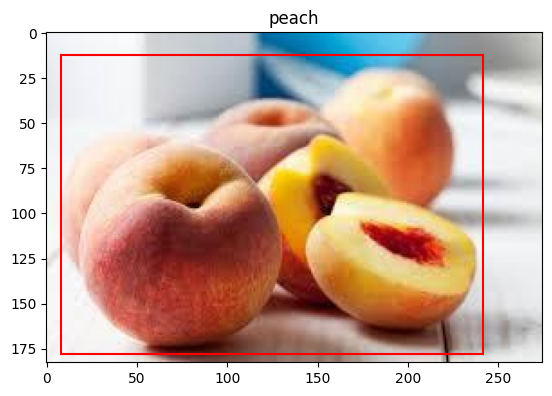

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from PIL import Image
import numpy as np
import json
import matplotlib
import matplotlib.pyplot as plt
import cv2
import os

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

### Sample code for visualisation
%matplotlib inline

labels = ['peach', 'nectarine', 'orange', 'mandarin', 'lingonberry', 'cranberry', 'plum', 'apricot']

def draw_rectangle(ax, top_left_x, top_left_y, width, height, color='red'):
    top_left = (top_left_x, top_left_y)
    bottom_right = (top_left_x + width, top_left_y + height)

    # Plotting each edge of the rectangle on the specified axes
    ax.plot([top_left[0], top_left[0]], [top_left[1], bottom_right[1]], '-', color=color)  # Left edge
    ax.plot([bottom_right[0], bottom_right[0]], [top_left[1], bottom_right[1]], '-', color=color)  # Right edge
    ax.plot([top_left[0], bottom_right[0]], [top_left[1], top_left[1]], '-', color=color)  # Top edge
    ax.plot([top_left[0], bottom_right[0]], [bottom_right[1], bottom_right[1]], '-', color=color)  # Bottom edge

#Reading in image filenames
train_dirname ='team16_codebreakers/data/train/images/'
test_dirname = 'team16_codebreakers/data/test/images/'
train_filenames=[]
test_filenames = []

for _,_,filenames in os.walk(train_dirname):
    for filename in filenames:
        train_filenames.append((train_dirname+filename,filename))
for _,_,filenames in os.walk(test_dirname):
    for filename in filenames:
        test_filenames.append((test_dirname+filename,filename))

#Image visualisation with bounding box
idx=501
img=Image.open(train_filenames[idx][0])
train_csv=pd.read_csv('team16_codebreakers/data/train.csv')
row=train_csv.loc[train_csv['filename']==train_filenames[idx][1]].iloc[0]
print("Image file",train_filenames[idx])
print("Corresponding info",row)

top_left_x = int(row['xmin'])
top_left_y = int(row['ymin'])
width = int(row['xmax']) - int(row['xmin'])+1
height = int(row['ymax']) - int(row['ymin'])+1

# Plot the image and the bbox
fig, ax = plt.subplots()
ax.imshow(img)
draw_rectangle(ax, top_left_x, top_left_y, width, height)
plt.title(labels[row['class']])
plt.show()

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:

def iou_xyxy(box_a, box_b):
    """IoU of two *single* (xmin,ymin,xmax,ymax) boxes"""
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_w = max(0, min(xa2, xb2) - max(xa1, xb1))
    inter_h = max(0, min(ya2, yb2) - max(ya1, yb1))
    inter   = inter_w * inter_h

    area_a  = (xa2 - xa1) * (ya2 - ya1)
    area_b  = (xb2 - xb1) * (yb2 - yb1)
    union   = area_a + area_b - inter + 1e-9          # ε for safety

    return inter / union

In [3]:
from torch.utils.data import Dataset
from transformers import AutoImageProcessor
from PIL import Image
import torch

class CSVObjectDetectionDataset(Dataset):
    """
    A Dataset for <filename,xmin,ymin,xmax,ymax,class> CSV annotations.

    Parameters
    ----------
    csv_file : str | os.PathLike
        Path to the CSV with one row per image.
    img_dir : str | os.PathLike
        Directory that contains all the image files.
    transform : albumentations.core.composition.Compose | None
        Albumentations pipeline to apply (may include bboxes!).
    return_path : bool
        If True, __getitem__ also returns the image file path (handy for debugging).
    """

    def __init__(self, csv_file, img_dir, transform=None, return_path=False):
        self.df         = pd.read_csv(csv_file)
        self.img_dir    = img_dir
        self.transform  = transform      # Albumentations pipeline
        self.return_path = return_path

        # (optional) work out how many classes you have
        self.classes    = sorted(self.df["class"].unique())
        self.num_classes = len(self.classes)

        # Pre-compute image paths so we don’t waste time in __getitem__
        self.filepaths  = self.df["filename"].apply(lambda f: os.path.join(img_dir, f)).tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img_path  = self.filepaths[idx]

        # ---- 1. read the image ------------------------------------------------
        image     = cv2.imread(img_path)          # BGR uint8 (Albumentations default)
        if image is None:
            raise FileNotFoundError(img_path)
        oh, ow, _   = image.shape

        # ---- 2. get the single annotation ------------------------------------
        bbox   = [row.xmin, row.ymin, row.xmax, row.ymax]   # Pascal VOC (xyxy)
        label  = int(row["class"])

        # ---- 3. Albumentations augmentation ----------------------------------
        if self.transform is not None:
            transformed = self.transform(
                image=image,
                bboxes=[bbox],            # keep as list – pipeline may drop it
                class_labels=[label],     # required by bbox_params
            )
            image = transformed["image"]
            # Albumentations returns bboxes in the SAME format you specified:
            # list of [xmin, ymin, xmax, ymax]
            bbox  = transformed["bboxes"][0]     # still one object/image
            label = transformed["class_labels"][0]

            # New spatial size (needed for area / normalising later)
            h, w = image.shape[:2]

        # ---- 4. build a target dict in *Pascal VOC* xyxy absolute px ----------  
        # This is perfect for the HF image-processor later.
        xmin, ymin, xmax, ymax = bbox
        area = (xmax - xmin) * (ymax - ymin)
        target = {
            "image_id"  : torch.tensor([idx]),
            "boxes"     : torch.tensor([[xmin, ymin, xmax, ymax]], dtype=torch.float32),
            "labels"    : torch.tensor([label], dtype=torch.int64),
            "area"      : torch.tensor([area], dtype=torch.float32),
            "iscrowd"   : torch.zeros((1,), dtype=torch.int64),   # always 0
            "orig_size" : torch.tensor([oh, ow]),                  
        }

        # ---- 5. convert image to CHW float32 – leave normalisation to HF processor
        image = torch.as_tensor(image.transpose(2, 0, 1), dtype=torch.float32)

        if self.return_path:
            return image, target, img_path
        return image, target

processor = AutoImageProcessor.from_pretrained("microsoft/conditional-detr-resnet-50",
                                                do_resize=False)
def collate_fn(batch):
    # batch = list of (image, target) tuples
    images, anns = [], []
    for img, tgt in batch:
        images.append(img.permute(1, 2, 0).numpy())         # CHW → HWC, still uint8
        xmin, ymin, xmax, ymax = tgt["boxes"][0].tolist()
        anns.append(
            {
                "image_id": int(tgt["image_id"][0]),
                "annotations": [
                    {
                        "category_id": int(tgt["labels"][0]),
                        "bbox": [xmin, ymin, xmax - xmin, ymax - ymin],  # COCO xywh
                        "area": float(tgt["area"][0]),
                        "iscrowd": 0,
                    }
                ],
            }
        )

    # one call — processor handles resizing, padding, masks, normalisation
    batch_enc = processor(images=images,
                          annotations=anns,
                          return_tensors="pt")

    # batch_enc already contains:
    #   pixel_values  -> (B, 3, H_pad, W_pad)
    #   pixel_mask    -> (B, H_pad, W_pad)
    #   labels        -> list[dict] with cxcywh boxes in [0,1]
    return batch_enc


c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
from torch.utils.data import random_split, DataLoader
import albumentations as A

train_tfms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,  
                           rotate_limit=30, p=0.5),
        A.Resize(480, 480),
        A.RandomBrightnessContrast(0.2, 0.2, p=0.5),        
        A.HueSaturationValue(1, 30, 30, p=0.5),
        #A.GaussianBlur(blur_limit=(5, 5), p=0.3),
        A.GaussNoise(std_range=[0.05, 0.1], p=0.4),
        #A.ISONoise(color_shift=[0.1, 0.5], intensity=[0.1, 0.5], p=0.8),
        #A.MotionBlur(blur_limit=[10, 10])

    ],
    bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]),
)
val_tfms = A.Compose(
    [
        A.Resize(480, 480),
    ],
    bbox_params=A.BboxParams(format="pascal_voc", label_fields=["class_labels"]),
)

dataset = CSVObjectDetectionDataset('team16_codebreakers/data/train.csv', 'team16_codebreakers/data/train/images', train_tfms, None)

val_fraction = 0.20                # 20 % for validation
val_len      = int(len(dataset)*val_fraction)
train_len    = len(dataset) - val_len

# reproducible shuffling
train_ds, val_ds = random_split(
        dataset,
        lengths=[train_len, val_len],
        generator=torch.Generator().manual_seed(42)  
)

val_ds.augmentations = val_tfms
train_dl = DataLoader(train_ds,
                       batch_size=24, 
                       collate_fn=collate_fn, 
                       shuffle=True)
val_dl = DataLoader(
        val_ds,
        batch_size=24,
        collate_fn=collate_fn,
        shuffle=False)          # keep order stable during evaluation

c:\Users\Gordei\Desktop\Univer 2\4 sem\compviz\Project\.venv\Lib\site-packages\albumentations\core\validation.py:111: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
print(train_ds[0][0].shape)
train_ds[0][1]

torch.Size([3, 480, 480])


{'image_id': tensor([864]),
 'boxes': tensor([[195.4639, 174.2085, 309.2784, 261.3127]]),
 'labels': tensor([7]),
 'area': tensor([9913.7207]),
 'iscrowd': tensor([0]),
 'orig_size': tensor([259, 194])}

In [6]:
from tqdm import tqdm

class Trainer:
    def __init__(self,
                 max_epochs, 
                 model,
                 optimizer,
                 device,
                 scaler,
                 train_loader,
                 valid_loader,
                 test_loader,
                 score_thr = 0.3,
				 log_every_n_steps=50,
                 scheduler=None,
                 chkpt_dir = '.',
                 start_epoch_number=0,
    ) -> None:
        """_summary_

        Args:
            max_epochs (int): For how many epoch to train
            model (): Model to train
            optimizer (torch.optim.Optimizer): Optimizer to use for training
            device (str): Which device to train on
            train_loader (DataLoader): Traing dataloader
            valid_loader (DataLoader): Validation dataloader
            test_loader (DataLoader): Test dataloader
            log_every_n_steps (int, optional): How many batches between updating progress. Defaults to 50.
            scheduler (torch.optim.lr_scheduler.Scheduler, optional): Learning rate scheduler to use. Defaults to None.
        """
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.scaler = scaler
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader
        self.max_epochs = max_epochs
        self.log_every_n_steps = log_every_n_steps
        self.chkpt_dir = chkpt_dir
        self.start_epoch = start_epoch_number
        self.score_thr = score_thr



        self.train_losses = []
        self.train_accs = []
        self.valid_losses = []
        self.valid_accs = []
        self.valid_ious = []

        self.best_iou = -np.inf

    def train_step(self):
        self.model.train()
        running_loss = 0.0
        pbar = tqdm(self.train_loader, desc="Training")

        for batch_idx, batch in enumerate(pbar):
            batch['pixel_values'] = batch['pixel_values'].to(self.device)
            batch['pixel_mask'] = batch['pixel_mask'].to(self.device)
            labels = batch['labels']
            for i in range(len(labels)):
                labels[i] = {k: v.to(self.device) for k, v in labels[i].items()}
            batch['labels'] = labels

            with torch.amp.autocast('cuda'):  
                outputs = self.model(**batch)
                loss = outputs.loss 
                
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)                             
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.1)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            self.optimizer.zero_grad(set_to_none=True)    # faster than zeroing to 0
            running_loss += loss.item()

            if batch_idx % self.log_every_n_steps == 0 or batch_idx==len(self.train_loader)-1:
                if batch_idx == 0: continue
                avg_loss = running_loss / batch_idx
                pbar.set_postfix(loss=f"{avg_loss:.4f}")
                
        return avg_loss

    def valid_step(self, to_print=False):
        self.model.eval()
        running_loss = 0.0
        all_pred_bboxes, all_pred_classes = [], []
        all_true_bboxes, all_true_classes = [], []

        with torch.no_grad():
            pbar = tqdm(self.valid_loader, desc="Validation")

            for batch_idx, batch in enumerate(pbar):
                batch['pixel_values'] = batch['pixel_values'].to(self.device)
                batch['pixel_mask'] = batch['pixel_mask'].to(self.device)
                labels = batch['labels']
                for i in range(len(labels)):
                    labels[i] = {k: v.to(self.device) for k, v in labels[i].items()}
                batch['labels'] = labels

                with torch.amp.autocast('cuda'):  
                    outputs = self.model(**batch)
                    loss = outputs.loss     

                running_loss += loss.item()
                
                true_boxes_xyxy, true_classes, pred_bboxes_xyxy, pred_labels = self.to_bboxes(batch, outputs, to_print=to_print)

                all_true_bboxes += list(true_boxes_xyxy)
                all_true_classes += list(true_classes)
                all_pred_bboxes += list(pred_bboxes_xyxy)
                all_pred_classes += list(pred_labels)
                

                if batch_idx % self.log_every_n_steps == 0 or batch_idx==len(self.valid_loader)-1:
                    if batch_idx == 0: continue
                    avg_loss = running_loss / batch_idx
                    pbar.set_postfix(loss=f"{avg_loss:.4f}")
    
        all_true_classes = np.array(all_true_classes)
        all_pred_classes = np.array(all_pred_classes)

        acc = np.mean(all_true_classes == all_pred_classes)
        ious = []
        for i in range(len(all_true_bboxes)):
            if all_pred_bboxes[i] is None:
                ious.append(0)
                continue
            iou = iou_xyxy(all_pred_bboxes[i], all_true_bboxes[i])
            ious.append(iou)
        avg_iou = np.mean(ious)
        return avg_loss, acc, avg_iou

    def to_bboxes(self, batch, output, to_print=False):
        batch_size = output.logits.shape[0]
        results = processor.post_process_object_detection(
                output,
                threshold=self.score_thr,
                target_sizes=torch.tensor([[1, 1]]*batch_size, device=self.device),
            )
        pred_bboxes_xyxy = []  
        pred_labels = []
        for result in results:
            if len(result["scores"]) > 0:
                # take highest-confidence prediction
                best = result["scores"].argmax().item()
                bbox = [v for v in result["boxes"][best].tolist()]  # In xmin, ymin, xmax, ymax
                label = int(result["labels"][best].item())
                pred_bboxes_xyxy.append(bbox)
                pred_labels.append(label)
            else:
                pred_bboxes_xyxy.append(None)
                pred_labels.append(None)


        true_boxes_xywh = [label['boxes'][0] for label in batch['labels']]  # In cx, cy, w, h
        true_classes = [label['class_labels'][0].cpu().numpy() for label in batch['labels']]
        true_boxes_xyxy = []
        for box in true_boxes_xywh:
            x, y, w, h = box
            xmin, ymin, xmax, ymax = x-w/2, y-h/2, x+w/2, y+h/2
            newbox = xmin, ymin, xmax, ymax
            newbox = [float(el.cpu().numpy()) for el in newbox]
            true_boxes_xyxy.append(newbox)
        if to_print:
            print('------')
            print('TRUE')
            print(true_classes)
            print('PRED')
            print(pred_labels)
        return true_boxes_xyxy, true_classes, pred_bboxes_xyxy, pred_labels
    

    def train(self):
        self.model.to(self.device)
        self.train_losses = []
        self.valid_losses = []
        self.valid_accs = []
        self.valid_ious = []

        for epoch in range(self.start_epoch, self.max_epochs):
            train_loss = self.train_step()
            valid_loss, valid_acc, valid_iou = self.valid_step()
 
        
            self.train_losses.append(train_loss)
            self.valid_losses.append(valid_loss)
            self.valid_ious.append(valid_iou)

            if valid_acc > self.best_iou:
                self.best_iou = valid_acc
                self.model.save_pretrained(f'{self.chkpt_dir}/epoch_{epoch}')
                print("Saved checkpoint!")

            if self.scheduler: self.scheduler.step()
            
            print(
                f"Epoch {epoch+1}/{self.max_epochs}: "
                f"train_loss: {train_loss:.4f}, "
                f"valid_loss: {valid_loss:.4f}, "
                f"valid_iou: {valid_iou:.2f}, "
                f"valid_acc: {valid_acc:.4f}, "
                )
        
        return self.train_losses, self.valid_ious, self.valid_accs


    def plot_metrics(self):
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))
        ax[0].plot(self.train_losses, label="train_loss", color="blue")
        ax[0].plot(self.valid_losses, label="valid_loss", linestyle="--", color="orange")
        ax[0].set_title("Losses")

        ax[1].plot(self.train_accuracies, label="train_acc", color="blue")
        ax[1].plot(self.valid_accuracies, label="valid_acc", linestyle="--", color="orange")
        ax[1].plot(self.valid_f1_scores, label="valid_macro_f1", linestyle="--", color="purple")
        ax[1].set_title("Accuracies")

        for i in range(2):
            ax[i].legend()
            ax[i].grid(0.35)
            ax[i].set_xlabel("Epochs")
        plt.show()

In [ ]:
from transformers import AutoImageProcessor, AutoModelForObjectDetection, TrainingArguments, ConditionalDetrConfig
def build_optimizer(model):
    def is_backbone(n): return "backbone" in n
    pg_backbone = [p for n,p in model.named_parameters() if is_backbone(n) and p.requires_grad]
    pg_transformer = [p for n,p in model.named_parameters() if not is_backbone(n) and p.requires_grad]

    return torch.optim.AdamW(
        [
            {"params": pg_backbone,    "lr": 1e-5},
            {"params": pg_transformer, "lr": 1e-4},
        ],
        weight_decay=1e-4)


labels = ['peach', 'nectarine', 'orange', 'mandarin', 'lingonberry', 'cranberry', 'plum', 'apricot']
label2id = {labels[i]:i for i in range(len(labels))}
id2label = {v:k for k, v in label2id.items()}

cfg = ConditionalDetrConfig.from_pretrained("team16_codebreakers/detrresnet50/epoch_69_512_084")
    cfg.matcher_class_cost = 4
    cfg.loss_ce_weight     = 4
cfg.id2label           = id2label        # <── add the dicts here
cfg.label2id           = label2id
cfg.num_labels         = len(id2label)   # good practice, not strictly required

model = AutoModelForObjectDetection.from_pretrained(
            "team16_codebreakers/detrresnet50/epoch_69_512_084",
            config=cfg,
            ignore_mismatched_sizes=True)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(device)
scaler = torch.amp.GradScaler(device)
opt = build_optimizer(model)
trainer = Trainer(80,
                  model,
                  opt,
                  device,
                  scaler,
                  train_dl,
                  val_dl,
                  None,
                  score_thr=0.01,
                  chkpt_dir = 'team16_codebreakers/detrresnet50',
                  )

In [9]:
trainer.train()

Validation: 100%|██████████| 14/14 [00:06<00:00,  2.13it/s, loss=3.6893]


Saved checkpoint!
Epoch 1/80: train_loss: 110.2150, valid_loss: 3.6893, valid_iou: 0.03, valid_acc: 0.1460, 


Validation: 100%|██████████| 14/14 [00:06<00:00,  2.16it/s, loss=2.1311]


Epoch 2/80: train_loss: 2.5186, valid_loss: 2.1311, valid_iou: 0.65, valid_acc: 0.1025, 


Validation: 100%|██████████| 14/14 [00:06<00:00,  2.15it/s, loss=1.6757]


...

Validation: 100%|██████████| 14/14 [00:06<00:00,  2.08it/s, loss=0.7794]


Epoch 79/80: train_loss: 0.5435, valid_loss: 0.7794, valid_iou: 0.88, valid_acc: 0.8106, 


Validation: 100%|██████████| 14/14 [00:06<00:00,  2.09it/s, loss=0.7955]

Epoch 80/80: train_loss: 0.5190, valid_loss: 0.7955, valid_iou: 0.88, valid_acc: 0.8075, 


([110.21501710279932,
  2.518574163598834,
  1.842806946556523,
  1.562531424018572,
  1.4679503620795484,
  1.3208287167099286,
  1.2772075455143768,
  1.2393121966775857,
  1.1826542559659705,
  1.1513427720879608,
  1.1462342008104864,
  1.079108325940258,
  1.0606007441034857,
  1.0289446621570948,
  1.0080160329926688,
  0.997879536646717,
  0.9761042583663508,
  0.9553943996159535,
  0.9540523628018936,
  0.9544298637588069,
  0.9186281561851501,
  0.9164712361569675,
  0.9030222521637971,
  0.8686234388711318,
  0.884581798652433,
  0.8732528191692425,
  0.8276750760258369,
  0.8314002324950021,
  0.8211525599911528,
  0.8172987924431855,
  0.7993845613497608,
  0.7902425122710893,
  0.7968916623097546,
  0.7642361577951683,
  0.7764966454146043,
  0.7692725489724357,
  0.7442788740374008,
  0.7599893178579942,
  0.742835521697998,
  0.7361817404908954,
  0.7210854291915894,
  0.7059298742492244,
  0.7143280146256933,
  0.7143063320303863,
  0.6809178793205405,
  0.7007112739221

In [ ]:
# max_epochs, 
#                  model,
#                  optimizer,
#                  device,
#                  scaler,
#                  train_loader,
#                  valid_loader,
#                  test_loader,

trainer = Trainer(10,
                  model,
                  opt,
                  device,
                  scaler,
                  train_dl,
                  val_dl,
                  None,
                  score_thr=0.1,
                  chkpt_dir = 'team16_codebreakers/detrresnet50',
                  )
trainer.valid_step(to_print=False)

Validation: 100%|██████████| 7/7 [00:02<00:00,  2.78it/s, loss=0.9175]


(0.9175374309221903, 0.7639751552795031, 0.8682997705188576)

In [13]:
from pathlib import Path
import csv

def infer_folder_to_csv(    
    model, 
    processsor,
    image_dir: str | os.PathLike,
    csv_out: str | os.PathLike = "submission.csv",
    score_threshold: float = 0.3,
    device: str | None = None,

):
    """
    Runs object detection on all images in `image_dir` and creates a CSV like
    filename,xmin,ymin,xmax,ymax,class

    * Keeps only the highest-score detection per image.
    * If no detection meets `score_threshold`, writes an all-zero box and class=-1.
    """
    image_dir = Path(image_dir)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Load model + processor ------------------------------------------------
    model.eval()

    # 2. Collect image files ---------------------------------------------------
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    files = [p for p in image_dir.iterdir() if p.suffix.lower() in exts]
    if len(files) == 0:
        raise RuntimeError(f"No images found in {image_dir}")

    rows = []

    # 3. Run inference image-by-image -----------------------------------------
    for img_path in files:
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        inputs = processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        print(outputs.pred_boxes)
        # post-process to VOC-xyxy absolute pixel boxes
        results = processor.post_process_object_detection(
            outputs,
            threshold=0.1,
            target_sizes=torch.tensor([[h, w]], device=device),
        )[0]
        print(results)

        if len(results["scores"]) > 0:
            # take highest-confidence prediction
            best = results["scores"].argmax().item()
            xmin, ymin, xmax, ymax = [int(v) for v in results["boxes"][best].tolist()]
            label = int(results["labels"][best].item())
        else:
            # nothing above threshold – write a dummy box & label
            xmin = ymin = 0
            xmax = w - 1
            ymax = h - 1
            label = -1                    # or 0, depending on competition rules

        rows.append([img_path.name, xmin, ymin, xmax, ymax, label])

    # 4. Write CSV -------------------------------------------------------------
    with open(csv_out, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "xmin", "ymin", "xmax", "ymax", "class"])
        writer.writerows(rows)

    print(f"✅ Wrote {len(rows)} predictions to {csv_out}")


In [14]:
infer_folder_to_csv(
    model, processor,
    image_dir="team16_codebreakers/data/test/images/",
    csv_out="team16_codebreakers/submission.csv",
    score_threshold=0.1,
)

tensor([[[0.8264, 0.7317, 0.4037, 0.6283],
         [0.7184, 0.1350, 0.6073, 0.6277],
         [0.9385, 0.5304, 0.3185, 0.6222],
         ...,
         [0.4459, 0.4330, 0.6952, 0.6576],
         [0.9284, 0.5064, 0.3679, 0.6782],
         [0.0686, 0.2956, 0.2747, 0.3224]]], device='cuda:0')
{'scores': tensor([0.8350], device='cuda:0'), 'labels': tensor([6], device='cuda:0'), 'boxes': tensor([[ 20.9728,  12.4314, 237.8329, 180.9731]], device='cuda:0')}
tensor([[[0.8321, 0.7292, 0.3328, 0.5125],
         [0.7068, 0.1477, 0.5238, 0.5931],
         [0.9395, 0.5430, 0.3677, 0.5942],
         ...,
         [0.4474, 0.4393, 0.6929, 0.6912],
         [0.9267, 0.5046, 0.4196, 0.6475],
         [0.0975, 0.3297, 0.5560, 0.6179]]], device='cuda:0')
{'scores': tensor([0.4243, 0.2932, 0.2886, 0.1245], device='cuda:0'), 'labels': tensor([6, 5, 1, 4], device='cuda:0'), 'boxes': tensor([[ 36.1200,  30.9876, 201.3471, 189.3528],
        [ 36.1200,  30.9876, 201.3471, 189.3528],
        [ 36.1200,  30.987

In [16]:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    competition = "team-16-codebreakers"          
    submission_file = "team16_codebreakers/submission.csv"  
    submission_message = "Submission Beta 1"
    api.competition_submit(submission_file, submission_message, competition)

100%|██████████| 15.0k/15.0k [00:00<00:00, 35.9kB/s]


{"message": "Successfully submitted to Team#16: Codebreakers", "ref": 44847947}